FIRE INCIDENTS

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

In [6]:
# Load dataset
fireIncidents = pd.read_csv("fireIncidents.csv", encoding = "latin1", low_memory = False)

In [7]:
fireIncidents.head()

,_id,call_no,incident_type,type_description,address,alarms,alarm_time,primary_unit,census_tract,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
0,1,F160029985,111.0,Building fire,"800 BLOCK CENTER ST, WILKINSBURG PA 15221",1,2016-04-21T05:01:04,231EN16,NaN,NaN,NaN,NaN,4.200356e+10,NaN,NaN,NaN,3-16,40.441275,-79.882485
1,2,F180022058,111.0,Building fire,"1100 BLOCK JANE ST, WILKINSBURG PA 15221",1,2018-03-13T08:34:43,231EN16,NaN,NaN,NaN,NaN,4.200356e+10,NaN,NaN,NaN,3-21,40.436342,-79.881003
2,3,F180022102,131.0,Passenger vehicle fire,"SB STATE HWY 28 SB AT 31S, PITTSBURGH PA 15212",0,2018-03-13T11:54:23,231EN32,2406.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1-1A,NaN,NaN
3,4,F170043431,131.0,Passenger vehicle fire,"1700 BLOCK BELLEAU DR, PITTSBURGH PA 15212",0,2017-05-31T08:39:47,231EN38,2509.0,Fineview,6.0,25.0,4.200325e+10,1.0,25.0,1.0,1-10,40.460303,-80.006980
4,5,F180021111,111.0,Building fire,"2400 BLOCK VILLAGE RD, PITTSBURGH PA 15205",1,2018-03-09T10:26:42,231EN31,2808.0,Fairywood,2.0,28.0,4.200356e+10,5.0,28.0,6.0,1-16,40.449009,-80.076607


In [8]:
fireIncidents["neighborhood"].unique()

array([nan, 'Fineview', 'Fairywood', 'South Side Flats',
       'Allegheny Center', 'Lincoln-Lemington-Belmar', 'Carrick',
       'Beechview', 'Allentown', 'Beltzhoover', 'Crafton Heights',
       'Homewood North', 'Squirrel Hill South', 'Perry North',
       'Bedford Dwellings', 'Homewood South', 'East Allegheny',
       'Crawford-Roberts', 'Sheraden', 'Middle Hill', 'Strip District',
       'East Hills', 'Garfield', 'Greenfield', 'North Shore',
       'Spring Hill-City View', 'Central Business District', 'Upper Hill',
       'Manchester', 'Overbrook', 'Polish Hill', 'Central Lawrenceville',
       'Brookline', 'Marshall-Shadeland', 'North Oakland',
       'South Oakland', 'Homewood West', 'East Liberty', 'Hazelwood',
       'Squirrel Hill North', 'Friendship', 'West Oakland',
       'Terrace Village', 'Brighton Heights', 'Troy Hill', 'Windgap',
       'Knoxville', 'Upper Lawrenceville', 'Arlington', 'Elliott',
       'South Side Slopes', 'Bloomfield', 'Perry South',
       'Central N

In [11]:
fire_counts = fireIncidents["neighborhood"].value_counts()
safest_neighborhoods = fire_counts.sort_values().head(10)
print("Safest Neighborhoods (Fewest fires Reported):")
print(safest_neighborhoods)

Safest Neighborhoods (Fewest fires Reported):
neighborhood
Mount Oliver Borough     7
Regent Square            9
East Carnegie           11
Ridgemont               12
Mt. Oliver              12
Arlington Heights       13
Oakwood                 13
St. Clair               15
Swisshelm Park          17
Chartiers City          18
Name: count, dtype: int64


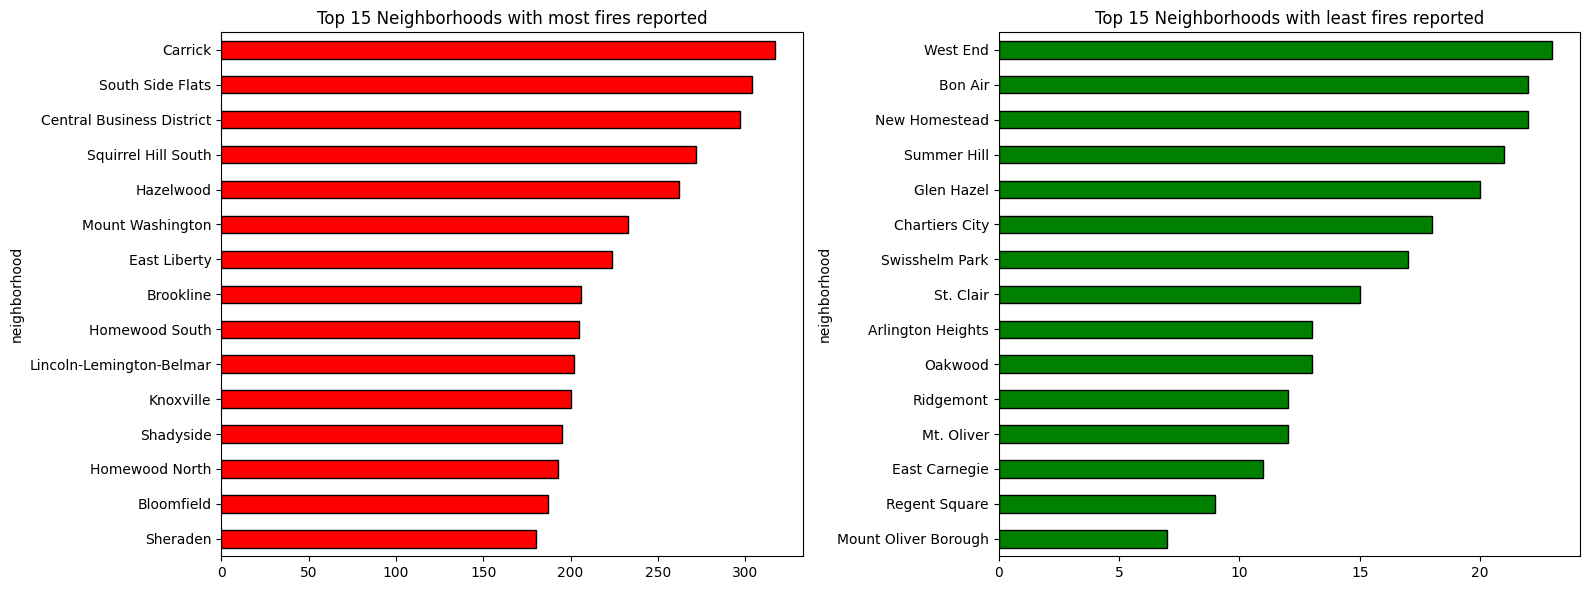

In [13]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))
fire_counts.head(15).plot(kind = "barh", ax = ax[0], color = "red", edgecolor = "black")
ax[0].set_title("Top 15 Neighborhoods with most fires reported")
ax[0].invert_yaxis()
fire_counts.tail(15).plot(kind = "barh", ax = ax[1], color = "green", edgecolor = "black")
ax[1].set_title("Top 15 Neighborhoods with least fires reported")
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

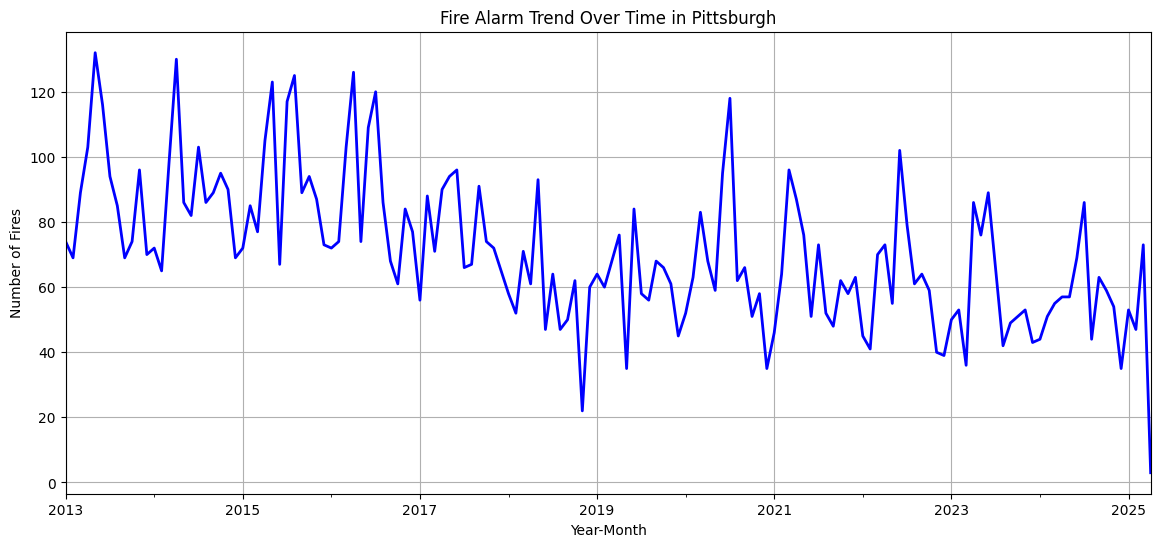

In [16]:
fireIncidents["alarm_time"] = pd.to_datetime(fireIncidents["alarm_time"], errors = "coerce")
fireIncidents["YEAR"] = fireIncidents["alarm_time"].dt.year
fireIncidents["MONTH"] = fireIncidents["alarm_time"].dt.to_period("M")
monthly_fires = fireIncidents["MONTH"].value_counts().sort_index()
plt.figure(figsize = (14, 6))
monthly_fires.plot(color = "blue", linewidth = 2)
plt.title("Fire Alarm Trend Over Time in Pittsburgh")
plt.xlabel("Year-Month")
plt.ylabel("Number of Fires")
plt.grid()

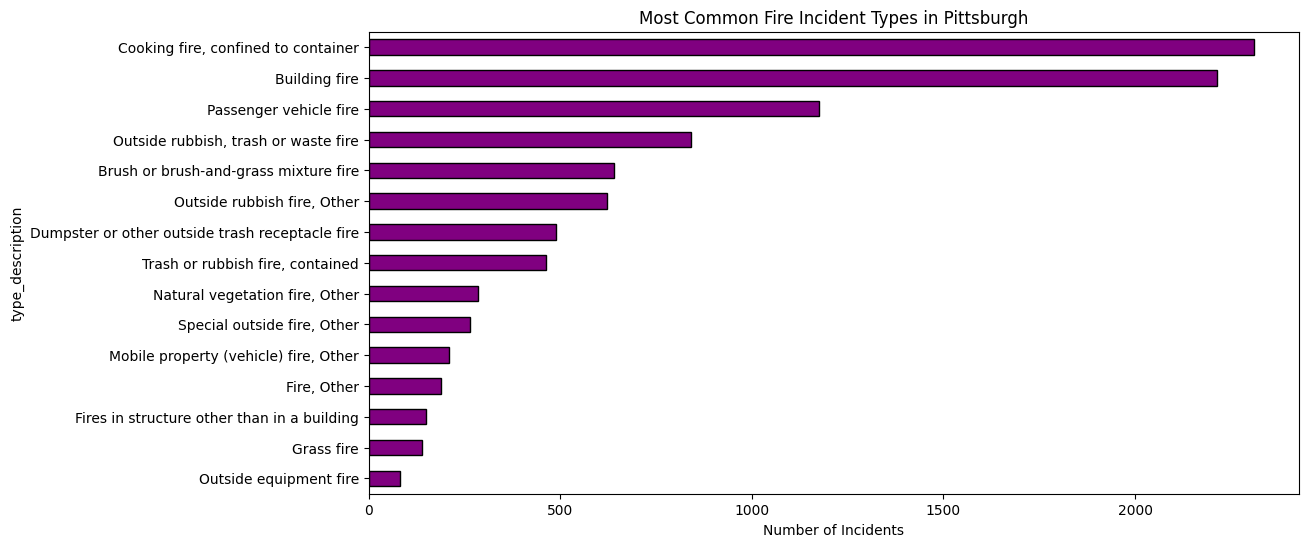

In [20]:
fire_types = fireIncidents["type_description"].value_counts()
plt.figure(figsize = (12, 6))
fire_types.head(15).plot(kind = "barh", color = "purple", edgecolor = "black")
plt.title("Most Common Fire Incident Types in Pittsburgh")
plt.xlabel("Number of Incidents")
plt.gca().invert_yaxis()
plt.show()

In [22]:
fire_data_filtered = fireIncidents.dropna(subset = ["latitude", "longitude"])
fire_data_filtered = fire_data_filtered[(fire_data_filtered["latitude"] != 0) & (fire_data_filtered["longitude"] != 0)]
f = folium.Map(location = [40.4406, -79.9959], zoom_start = 12)
HeatMap(data = fire_data_filtered[["longitude", "latitude"]], radius = 10).add_to(f)
f

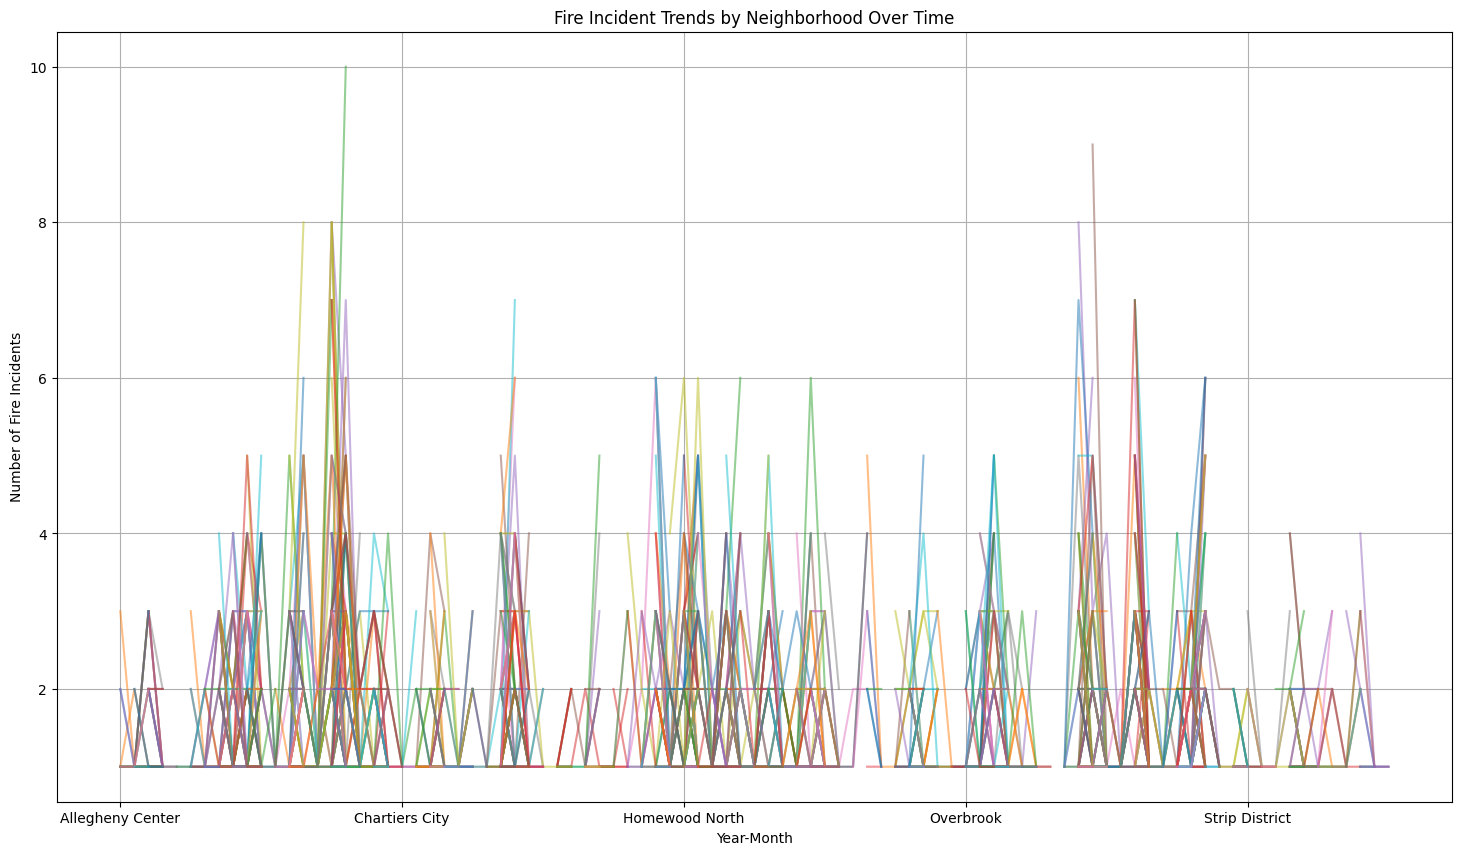

In [23]:
fire_by_neighborhood_month = fireIncidents.groupby(["MONTH", "neighborhood"]).size().unstack()
fire_by_neighborhood_month.T.plot(figsize = (18, 10), alpha = 0.5, legend = False)
plt.title("Fire Incident Trends by Neighborhood Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Fire Incidents")
plt.grid()
plt.show()

In [24]:
fire_trends = fire_by_neighborhood_month.diff().sum()
fire_trends.sort_values(ascending = False).head(5)

neighborhood
Garfield                 11.0
Spring Hill-City View    10.0
Bloomfield               10.0
Brookline                 9.0
Homewood South            9.0
dtype: float64

In [28]:
fireIncidents["YEAR"] = fireIncidents["alarm_time"].dt.year
fire_trend = fireIncidents.groupby(["YEAR", "neighborhood"]).size().unstack()
fire_trend_pct_change = fire_trend.pct_change(fill_method = None).fillna(0).mean().sort_values()
print("Neighborhoods with decreasing Fire Incidents:")
print(fire_trend_pct_change.head(10))
print("Neighborhoods with increasing Fire Incidents:")
print(fire_trend_pct_change.tail(10))

Neighborhoods with decreasing Fire Incidents:
neighborhood
West Oakland               -0.138500
Squirrel Hill North        -0.109407
Crawford-Roberts           -0.104945
Homewood North             -0.094973
Perry South                -0.094210
Middle Hill                -0.090182
East Liberty               -0.089032
Hazelwood                  -0.088248
Lincoln-Lemington-Belmar   -0.077103
Sheraden                   -0.075516
dtype: float64
Neighborhoods with increasing Fire Incidents:
neighborhood
Perry North            0.347371
Troy Hill              0.372747
Greenfield             0.374325
Upper Lawrenceville    0.376374
Strip District         0.380159
New Homestead          0.404762
Esplen                 0.416667
Manchester             0.458731
Hays                   0.615385
West End               0.692308
dtype: float64


In [ ]:
plt.figure(figsize = (12, 6))
top_neighborhoods = fire_trend.sum().nlargest(5).index
trend[top_neighborhoods].plot(figsize = (12, 6), linewidth = 2)
plt.title("Fire Incident Trend Over Time in Top 5 Neighborhoods")
plt.xlabel("Year")
plt.ylabel("Fire Incident Count")
plt.legend(title = "Neighborhoods")
plt.grid(True)
plt.show()